In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("House_Rent_Dataset.csv")
print("Dataset loaded:", df.shape)
df.head()

Dataset loaded: (4746, 12)


,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [2]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (4746, 12)

Columns: ['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type', 'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred', 'Bathroom', 'Point of Contact']


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Posted On          4746 non-null   str  
 1   BHK                4746 non-null   int64
 2   Rent               4746 non-null   int64
 3   Size               4746 non-null   int64
 4   Floor              4746 non-null   str  
 5   Area Type          4746 non-null   str  
 6   Area Locality      4746 non-null   str  
 7   City               4746 non-null   str  
 8   Furnishing Status  4746 non-null   str  
 9   Tenant Preferred   4746 non-null   str  
 10  Bathroom           4746 non-null   int64
 11  Point of Contact   4746 non-null   str  
dtypes: int64(4), str(8)
memory usage: 445.1 KB


In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
pd.DataFrame({'count': missing, 'percent': missing_pct.round(1)}).head(10)

,count,percent
Posted On,0,0.0
BHK,0,0.0
Rent,0,0.0
Size,0,0.0
Floor,0,0.0
Area Type,0,0.0
Area Locality,0,0.0
City,0,0.0
Furnishing Status,0,0.0
Tenant Preferred,0,0.0


In [5]:
# Duplicates
print("Duplicate rows:", df.duplicated().sum())

# Unique values per column
df.nunique().sort_values()

Duplicate rows: 0


Area Type               3
Furnishing Status       3
Tenant Preferred        3
Point of Contact        3
BHK                     6
City                    6
Bathroom                8
Posted On              81
Rent                  243
Floor                 480
Size                  615
Area Locality        2235
dtype: int64

In [4]:
df.describe().round(2)

,BHK,Rent,Size,Bathroom
count,4746.00,4746.00,4746.00,4746.00
mean,2.08,34993.45,967.49,1.97
std,0.83,78106.41,634.20,0.88
min,1.00,1200.00,10.00,1.00
25%,2.00,10000.00,550.00,1.00
50%,2.00,16000.00,850.00,2.00
75%,3.00,33000.00,1200.00,2.00
max,6.00,3500000.00,8000.00,10.00


In [7]:
# Skewness — high value means skewed
df.skew(numeric_only=True).sort_values(ascending=False).round(2)

Rent        21.41
Size         2.30
Bathroom     1.27
BHK          0.60
dtype: float64

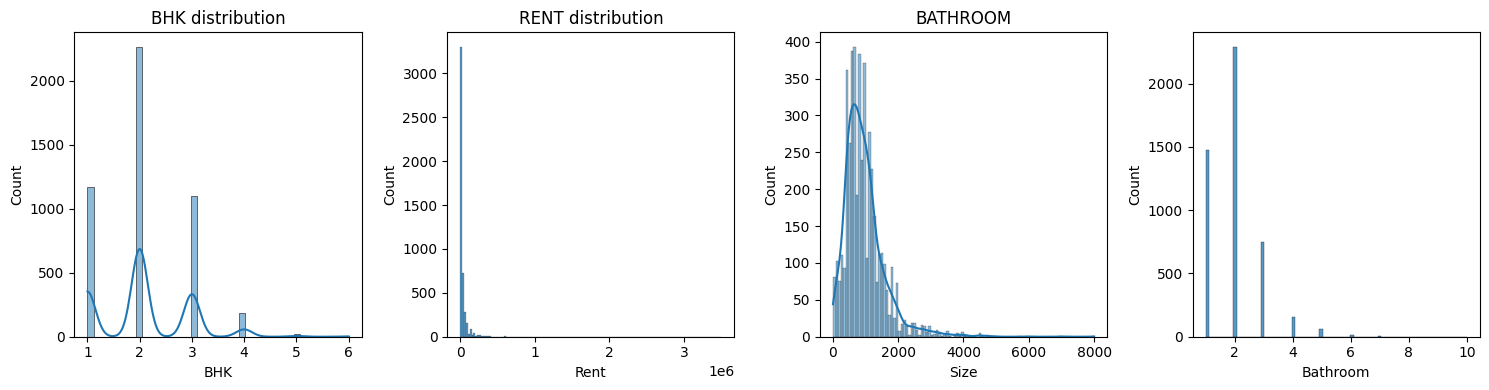

In [10]:
# Histograms for numeric columns
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

sns.histplot(df['BHK'], kde=True, ax=axes[0])
axes[0].set_title('BHK distribution')

sns.histplot(df['Rent'], kde=False, ax=axes[1])
axes[1].set_title('RENT distribution')

sns.histplot(df['Size'], kde=True, ax=axes[2])
axes[2].set_title('SIZE DISTRIBUTUION')

sns.histplot(df['Bathroom'], kde=False, ax=axes[3])
axes[2].set_title('BATHROOM')

plt.tight_layout()
plt.show()

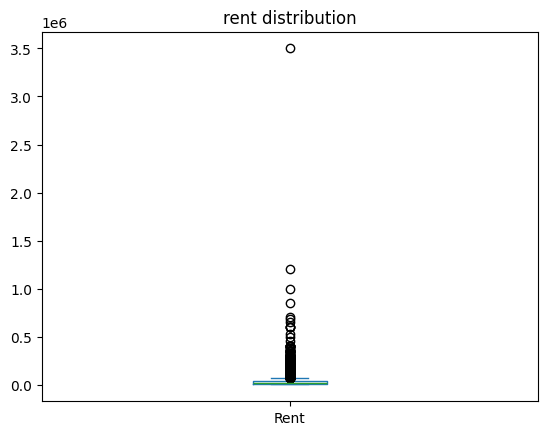

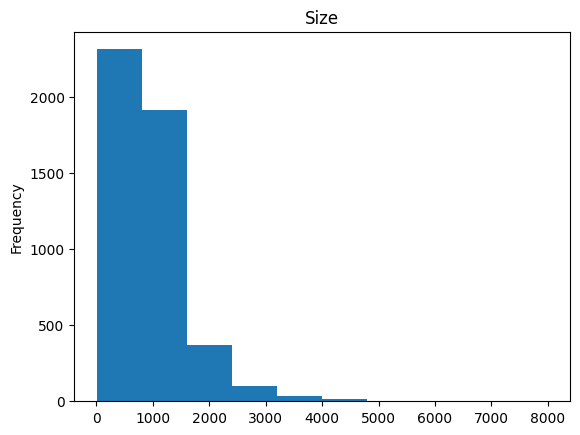

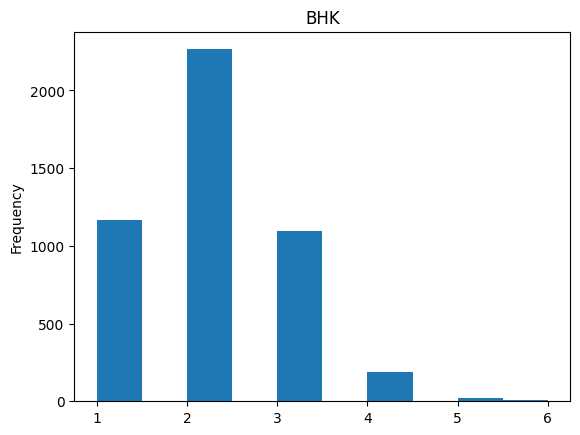

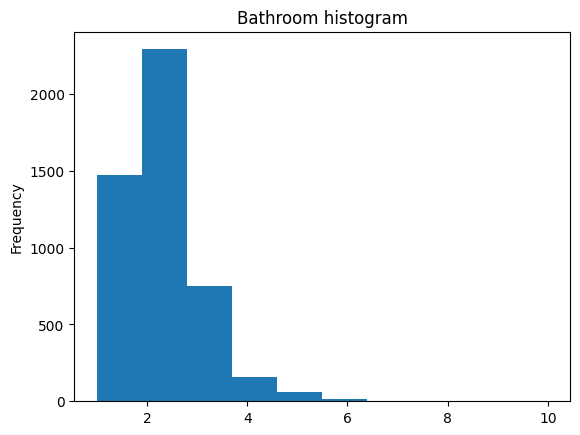

In [17]:
df['Rent'].plot(kind='box', title='rent distribution')
plt.show()

df['Size'].plot(kind='hist', bins=10, title='Size')
plt.show()
df['BHK'].plot(kind='hist', bins=10, title='BHK')
plt.show()
df['Bathroom'].plot(kind='hist', bins=10, title='Bathroom histogram')
plt.show()


In [7]:
Q1 = df['Rent'].quantile(0.25)
Q3 = df['Rent'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower bound: {lower:.0f}")
print(f"Upper bound: {upper:.0f}")

Q1: 10000.0
Q3: 33000.0
IQR: 23000.0
Lower bound: -24500
Upper bound: 67500


In [8]:
outliers_iqr = df[(df['Rent'] < lower) | (df['Rent'] > upper)]
print("Outliers detected by IQR:")
outliers_iqr

Outliers detected by IQR:


,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
104,2022-06-16,2,180000,950,Ground out of 1,Carpet Area,"Avenue S, Santoshpur",Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
525,2022-06-14,2,70000,750,4 out of 10,Carpet Area,Santacruz West,Mumbai,Furnished,Bachelors/Family,2,Contact Agent
527,2022-05-27,3,75000,1100,2 out of 13,Carpet Area,"Sabari Palm View, Chembur",Mumbai,Unfurnished,Family,3,Contact Agent
530,2022-06-20,2,160000,800,14 out of 14,Carpet Area,parivar safalya chs,Mumbai,Unfurnished,Bachelors/Family,2,Contact Owner
531,2022-07-07,4,300000,1600,43 out of 78,Carpet Area,"Trump Tower, Worli",Mumbai,Semi-Furnished,Bachelors/Family,5,Contact Agent
...,...,...,...,...,...,...,...,...,...,...,...,...
4523,2022-06-21,3,70000,2780,4 out of 26,Super Area,Nanakram Guda,Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent
4543,2022-06-11,4,200000,4761,1 out of 35,Carpet Area,K P H B Phase 4,Hyderabad,Semi-Furnished,Bachelors,6,Contact Owner
4648,2022-07-06,6,80000,4500,1 out of 2,Super Area,"Kakateeya Nagar, Secunderabad",Hyderabad,Semi-Furnished,Bachelors/Family,6,Contact Owner
4669,2022-07-06,4,140000,3789,9 out of 22,Carpet Area,"Gachibowli CUC, Outer Ring Road",Hyderabad,Semi-Furnished,Family,5,Contact Agent


In [9]:
df['Rent_log'] = np.log1p(df['Rent'])  # log1p = log(1+x), safe for zeros
print("Original vs log-transformed:")
print(df[['Rent','Rent_log']])

Original vs log-transformed:
       Rent   Rent_log
0     10000   9.210440
1     20000   9.903538
2     17000   9.741027
3     10000   9.210440
4      7500   8.922792
...     ...        ...
4741  15000   9.615872
4742  29000  10.275086
4743  35000  10.463132
4744  45000  10.714440
4745  15000   9.615872

[4746 rows x 2 columns]


In [ ]:
df['Bathroom'].value_counts()



BHK
2    2265
1    1167
3    1098
4     189
5      19
6       8
Name: count, dtype: int64

In [28]:
Q1 = df['Bathroom'].quantile(0.25)
Q3 = df['Bathroom'].quantile(0.75)
IQR = Q3 - Q1

Bathlower = Q1 - 1.5 * IQR
Bathupper = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower bound: {lower:.0f}")
print(f"Upper bound: {upper:.0f}")

df_removed = df[(df['Bathroom'] >= Bathlower) & (df['Bathroom'] <= Bathupper)]
print("After removing outliers:")
print(df_removed[['Bathroom']])
df.head()

Q1: 1.0
Q3: 2.0
IQR: 1.0
Lower bound: -0
Upper bound: 4
After removing outliers:
      Bathroom
0            2
1            1
2            1
3            1
4            1
...        ...
4741         2
4742         3
4743         3
4744         2
4745         2

[4514 rows x 1 columns]


,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,Rent_log
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,9.210440
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,9.903538
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,9.741027
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,9.210440
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner,8.922792


In [36]:
df_removed['BHK'].value_counts()
#df_removed['Size'].value_counts()
# df_removed.describe()

BHK
2    2263
1    1165
3    1037
4      45
5       3
6       1
Name: count, dtype: int64

In [37]:
# Skewness — high value means skewed
df_removed.skew(numeric_only=True).sort_values(ascending=False).round(2)

Rent        40.89
Size         1.13
Rent_log     0.72
BHK          0.23
Bathroom     0.21
dtype: float64

In [39]:
Q1 = df_removed['Size'].quantile(0.25)
Q3 = df_removed['Size'].quantile(0.75)
IQR = Q3 - Q1

Slower = Q1 - 1.5 * IQR
Supper = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower bound: {lower:.0f}")
print(f"Upper bound: {upper:.0f}")

df_removed[(df_removed['Size'] > Supper) | (df_removed['Size'] < Slower)]

Q1: 550.0
Q3: 1150.0
IQR: 600.0
Lower bound: -0
Upper bound: 4


,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,Rent_log
181,2022-05-13,1,50000,2200,2 out of 5,Super Area,Kanchrapara,Kolkata,Furnished,Bachelors/Family,3,Contact Owner,10.819798
267,2022-06-24,1,6000,2160,1 out of 2,Super Area,Kasba,Kolkata,Semi-Furnished,Bachelors,1,Contact Owner,8.699681
275,2022-07-04,4,30000,4000,Ground out of 3,Super Area,"Sakher Bazar, Purba Barisha",Kolkata,Furnished,Bachelors/Family,3,Contact Agent,10.308986
381,2022-06-08,3,40000,3500,1 out of 2,Super Area,Salt Lake City,Kolkata,Semi-Furnished,Bachelors/Family,2,Contact Owner,10.596660
516,2022-06-05,3,65000,2210,Ground out of 2,Carpet Area,"Vedic Village, Rajarhat",Kolkata,Unfurnished,Bachelors/Family,3,Contact Owner,11.082158
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4670,2022-07-06,3,65000,2700,2 out of 5,Carpet Area,Jubilee Hills,Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent,11.082158
4671,2022-06-18,3,60000,2170,4 out of 5,Carpet Area,Kakatiya Hills Madhapur,Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner,11.002117
4698,2022-07-02,3,53000,2300,1 out of 5,Carpet Area,"Banjara Hills, NH 9",Hyderabad,Furnished,Bachelors,3,Contact Agent,10.878066
4712,2022-07-06,3,60000,2405,10 out of 14,Super Area,"Manikonda, Outer Ring Road",Hyderabad,Semi-Furnished,Bachelors,3,Contact Agent,11.002117


In [11]:
print(df['Rent'].describe())
print("\nProperties above 10 lakhs:", (df['Rent'] > 1000000).sum())

count    4.746000e+03
mean     3.499345e+04
std      7.810641e+04
min      1.200000e+03
25%      1.000000e+04
50%      1.600000e+04
75%      3.300000e+04
max      3.500000e+06
Name: Rent, dtype: float64

Properties above 10 lakhs: 2


In [12]:
df.corr(numeric_only=True)['Rent'].sort_values().round(3)

BHK         0.370
Size        0.414
Bathroom    0.441
Rent        1.000
Name: Rent, dtype: float64

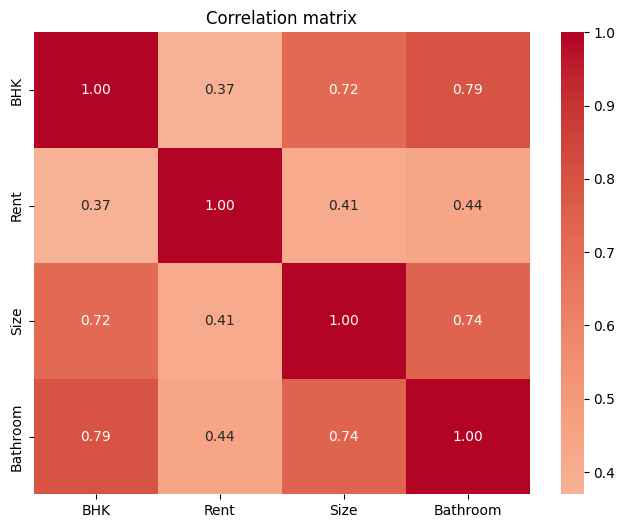

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True, fmt='.2f', cmap='coolwarm', center=0
)
plt.title('Correlation matrix')
plt.show()

In [10]:
print(df['Size'].describe())

Q1 = df['Size'].quantile(0.25)
Q3 = df['Size'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

print(f"\nIQR Upper bound: {upper}")
print("\nSize outlier rows:")
df[df['Size'] > upper][['Size', 'BHK', 'City', 'Rent_log']].sort_values('Size', ascending=False)

count    4746.000000
mean      967.490729
std       634.202328
min        10.000000
25%       550.000000
50%       850.000000
75%      1200.000000
max      8000.000000
Name: Size, dtype: float64

IQR Upper bound: 2175.0

Size outlier rows:


,Size,BHK,City,Rent_log
4185,8000,1,Hyderabad,12.206078
4457,7000,4,Hyderabad,12.899222
3622,6000,5,Chennai,11.512935
2048,5700,4,Bangalore,12.429220
1001,5000,4,Mumbai,13.997833
...,...,...,...,...
2610,2200,3,Delhi,9.952325
2609,2200,3,Delhi,10.463132
2432,2200,2,Delhi,11.289794
1882,2200,3,Bangalore,10.714440
